# Implementing `Co-Clustering Triples from Open Information Extraction" by Pal, Ho, and Weikum` From Scratch

## 1. Motivation and Problem Statement
At core of this paper it tackles the "messiness" of information extracted from raw text all over the internet.<br>
Imagine we have systems called Open Information Extraction (Open IE) that read billions of sentences from the web and try to distill them into simple facts. These facts are stored as triples: (Subject, Predicate, Object), or (SPO). 
For example, `New Delhi is India's capital` becomes $(New Delhi, is capital of, India).$

This process is powerful but it also ends up creating two major problems:

- **Redundancy and Ambiguity**:  
  Natural human language is flexible therefore the same fact can be written in many ways. For example, `(Apple, was founded by, Steve Jobs)` and `(Apple, was started by, Steve Jobs)` are semantically identical. This is **redundancy**.  
  Conversely, a single predicate can have completely different meanings depending on the context.  
  For example consider the triples `(lion, attack, zebra)` versus `(student, attack, problem)`.  
  The predicate "attack" here is used in two vastly different senses i.e. **ambiguity**[.

- **Predicate Imbalance**:  
  A few generic verbs like "is a", "have", and "include" appear often covering a huge percentage of all extracted triples.  
  Whereas at the same time there's a "long tail" of highly specific and rare predicates that appear only a handful of times.  
  The generic predicates often tell nothing clearly about the true semantic relationship while the rare ones are too infrequent for most algorithms to learn from.

The core problem the paper addresses is the lack of **canonicalization**

> Adding to these issues is the problem of exact mismatch where triples may be semantically similar but represent different levels of specificity. For example when we say the fact (panda, are, endangered) is a general statement while (panda, are, endangered in China) is a more specific refinement. An ideal canonicalization system must be able to recognize the relationship between such statements.

## 2. Assumptions, Goals, and Research Questions

In response to the identified shortcomings of previous methods, Pal et al. propose a novel framework centered on the principles of soft co-clustering. The approach is designed not merely to group synonymous phrases but to perform a more sophisticated context-aware canonicalization that can handle the nuances of natural language as found in OIE triples.

### 2.1 The Core Idea: Jointly Clustering Predicates and Arguments

The central hypothesis of the paper is that the ambiguity of predicates can only be resolved by considering the semantic context provided by their arguments. Hence instead of clustering predicates and subject-object(SO) pairs in isolation the proposed method clusters them jointly and learns the alignment between these clusters. This concept is best illustrated by the paper's own example:

Given a set of triples including `(student, attack, problem)`, `(researcher, solve, problem)`, `(lion, attack, zebra)`, and `(lion, kill, zebra)` the desired output is not a single cluster for the predicate "attack." Instead of this the ideal output would be two distinct co-clusters:
1. A predicate cluster `{attack, solve}` aligned with an SO-pair cluster `{student-problem, researcher-problem}`.
2. A predicate cluster `{kill, attack}` aligned with an SO-pair cluster `{lion-zebra, lion-antelope}`.

This example perfectly explains the power of the co-clustering paradigm. It correctly differentiates the two senses of "attack" by aligning them with two semantically coherent, but distinct groups of arguments. This joint approach is the cornerstone of the paper's methodology which is designed to capture the interplay between what is being said (the predicate) and what it is being said about (the arguments).

### 2.2 The Three Goal of the Framework
The authors articulate three specific, interconnected goals that their soft-co-clustering framework aims to achieve: Normalization, Specialization, and Transfer Learning.

1. **Normalization:** This is the traditional goal of canonicalization i.e. to focus on reducing redundancy. It involves grouping together different predicate phrases that are semantically equivalent. For example, the model should learn to group predicates like "possess," "control," and "occupy" into a single conceptual cluster representing ownership or something dominant. This addresses the many-to-one mapping from various linguistic surface forms to a single underlying meaning.

2. **Specialization:** This is the paper's most significant and novel conceptual contribution. Specialization addresses the problem of polysemy i.e. the coexistence of many possible meanings for a word or phrase by forming context-specific clusters.<br>
It allows a single predicate to be assigned to multiple different clusters where each represent a specific sense or usage determined by its arguments. The paper here is using predicate "have" as an example. Depending on the SO-pairs it co-occurs with, "have" might be grouped with possessive predicates like "has part" (e.g., a car "has" an engine) or with biological predicates like "grow" and "form" (e.g., a tree "has" leaves). While Normalization is about finding synonyms specialization is used to find distinct senses.<br>
This addresses the one-to-many mapping from a single surface form to multiple context-dependent meanings i.e. a more sophisticated and realistic model of language that hard-clustering methods are fundamentally incapable of handling.

3. **Transfer Learning:** This goal highlights a beneficial side-effect of the clustering process demonstrating its potential for knowledge discovery similaar to knowledge base completion. By grouping entities and predicates based on semantic similarity the model can generalize learned patterns to derive new plausible facts. The paper's example is illustrative: i.e. if the model learns the fact `(lion, attack, zebra)` and also learns to cluster hyena with lion (because they appear in similar SO-pair contexts) it can potentially infer the new fact `(hyena, attack, zebra)`. This showcases the framework's ability not just to organize existing knowledge but also it can make it better.

### 2.3 Why Soft Clustering is Essential
The goal of Specialization makes the choice of a ***soft*** clustering mechanism non-negotiable. As seen in the past works that relied on "hard clustering" i.e. assigning each item to a single exclusive cluster is a major limitation when dealing with the polysemy of natural language.

Whereas soft clustering allows an item (a predicate or an SO-pair) to hold partial membership in multiple clusters at same time typically represented by a vector of likelihoods or probabilities. This is precisely the mechanism needed to enable Specialization. A predicate like "attack" can have a high membership score in the "predator-prey" cluster and at the same time a non-zero membership score in the "academic problem-solving" cluster. This allows the model to capture the multiple domain of a word's meaning without being forced into an wrong all-or-nothing decision.

## 3. The Mathematical Behind Idea of Tri-Factorization

To implement their soft-co-clustering framework the authors of paper adapt a powerful mathematical tool: **Non-Negative Matrix Tri-Factorization (NMTF).** This section provides a technically deep analysis of the model's architecture from its foundational principles to its specific optimization landscape.

### 3.1 Foundation with Matrix Factorization for Latent Semantics
At its base matrix factorization (MF) is a class of algorithms used in linear algebra and machine learning to decompose a matrix into a product of two or more lower-rank matrices. The central intuition is that these lower-rank "factor" matrices can reveal hidden structures or meaning within the original data.

A classic example is in recommender systems. Imagine a large matrix where rows represent users and columns represent movies with the entries being the ratings users have given. This matrix is likely very sparse (most users haven't rated most movies). MF decomposes this user-movie matrix into two smaller and denser matrices: a user-feature matrix and a movie-feature matrix.<br>
The user-feature matrix might learn hidden features for each user (e.g., preference for comedy, action, drama) while the movie-feature matrix learns corresponding hidden features or genre for each movie (e.g., degree of comedy, action, drama). By multiplying these factor matrices back together the model can predict the ratings for the missing entries effectively recommending movies to users. The key takeaway is that MF is a technique for discovering unobserved hidden dimensions that explain the observed interactions in the data. This principle is fundamental to understanding the  $U$, $W$, and $V$ matrices in the paper's model.

### 3.2 The Non-Negative Matrix Tri-Factorization (NMTF) Model

The paper employs a specific variant of Matrix Factorisation called Non-Negative Matrix Tri-Factorization. This approach is particularly well-suited for the task due to its interpretability and its ability to model three-way interactions.

#### 3.2.1 Constructing the Input Matrix $M$

The first step is to transform the raw set of SPO triples into a numerical matrix $M$. This matrix is constructed to represent the co-occurrence relationship between subject-object pairs and predicates.
- The matrix $M$ has dimensions $m×n$ where $m$ is the number of unique SO-pairs found in the data, and $n$ is the number of unique predicate phrases.

- Each row $i$ corresponds to a unique SO-pair (e.g., `student-problem`).

- Each column $j$ corresponds to a unique predicate (e.g., `attack`).

- The entry $M_{ij}$ is set to 1 if the SO-pair $i$ and the predicate $j$ co-occur in at least one triple in the dataset. Otherwise, $M_{ij=0}$

- The paper also shows that instead of a binary matrix the entries can be populated with the confidence scores of the extracted triples which allows the model to weigh more reliable facts more heavily.

#### 3.2.2 The Tri-Factorization Formula: $M \approx U W V^T$

The core of the model is the factorization of the input matrix $M$ into three distinct and non-negative factor matrices: $U$, $W$, and $V$. The approximation is expressed as:
$M_{m \times n} \approx U_{m \times k} \times W_{k \times l} \times V_{l \times n}^T$

Each of these matrices has a specific semantic role:

1. $U$**(The SO-Pair Cluster Membership Matrix):** This matrix has dimensions $m \times k$. Each row corresponds to an SO-pair and each column corresponds to one of $k$ hidden SO-pair clusters. The value $U_{i\mu}$ represents the degree of membership or likelihood that the $i_{th}$ SO-pair belongs to the $\mu_{th}$ latent cluster. $k$ is a hyperparameter representing the desired number of SO-pair clusters.

2. $V$**(The Predicate Cluster Membership Matrix):** This matrix has dimensions $n×l$. Each row corresponds to a predicate and each column corresponds to one of $l$ hidden predicate clusters. The value $V_{jv}$ represents the likelihood that the $j$-th predicate belongs to the $ν$-th hidden cluster.<br>
$l$ is a hyperparameter for the number of predicate clusters. The use of two different hyperparameters $k$ and $l$ gives upperhand to tri-factorization over methods like Singular Value Decomposition (SVD) as it allows the model to reflect the potentially different degrees of diversity and ambiguity in SO-pairs versus predicates.

3. $W$**(The Alignment Matrix):** This middle matrix with dimensions $k×l$ is the mathematical engine of the co-clustering. It does not represent items from the data directly but instead models the interactions between the clusters. The value $W_{μν}$ captures the strength of the alignment or association between the $μ$-th SO-pair cluster and the $ν$-th predicate cluster. A high value of $W_{μν}$ implies that SO-pairs in cluster $μ$ are highly likely to co-occur with predicates in cluster $ν$. This matrix is what allows the model to learn for example, that the "predator-prey" SO-pair cluster is strongly aligned with the "predatory action" predicate cluster.


### 3.3 The Optimization Landscape

The goal of the model is to find the matrices $U$, $W$, and $V$ that best approximate the original matrix $M$ while satisfying certain constraints. This is formulated as an optimization problem.

**Minimize:**

$\| M - U W V^T \|_F$

**Subject to:**
1. $U^T U = I$, $V^T V = I$  
2. $U, V, W \geq 0$


Now we deconstruct these constraints then:


- **The Objective Function** $\|\cdot \cdot \cdot\|_F$: The objective here is to minimize the Frobenius norm of the difference between the original matrix $M$ and its reconstruction $U W V^T$. <br>
The Frobenius norm is essentially the matrix equivalent of the Euclidean distance in straight line. Minimizing it is equivalent to minimizing the sum of the squared differences between each element of $M$ and the corresponding element in the reconstruction. This is the "data loss" term ensuring the factorization remains faithful to the original data.

- **Non-Negativity Constraint** $(U, V, W \geq 0)$: This is the most defining characteristic of NMF which we can guess it from name itself. By constraining all elements of the factor matrices to be non-negative the model is forced to learn a purely additive, parts-based representation. This is opposite to methods like SVD which allow negative values and can depend on cancellations. The non-negativity makes the resulting clusters more easily understandable as combinations of constituent parts.

- **Orthogonality Constraint** $(U^T U = I, V^T V = I)$: This constraint forces the column vectors within $U$ and $V$ (which represents the clusters) to be orthogonal to one another. This encourages the model to find distinct and non-overlapping cluster bases and is crucial for preserving the soft-clustering property during optimization.

#### Defining Solver using Multiplicative Update Rules

Solving this optimization problem is non-trivial. Due to the constraints defined above a simple closed-form solution via standard gradient descent is not readily available. The paper adopts an iterative approach based on the multiplicative update rules proposed by [Ding et al.](https://ranger.uta.edu/~chqding/papers/orthNMF.pdf) which have been shown to be effective for this type of constrained NMTF problem. The update rules are given by:


$U_{ij} \leftarrow U_{ij} \sqrt{ \frac{(MVW^T)_{ij}}{(UU^T MVW^T)_{ij}} }$


$V_{ij} \leftarrow V_{ij} \sqrt{ \frac{(M^T UW)_{ij}}{(VV^T M^T UW)_{ij}} }$


$W_{ij} \leftarrow W_{ij} \sqrt{ \frac{(U^T MV)_{ij}}{(U^T UWV^T V)_{ij}} }$

These update rules are applied iteratively. At every step the current values of $U$, $V$, and $W$ are used to compute updated values that move closer to minimizing the objective function while naturally preserving the non-negativity constraint (since all terms under the square root are non-negative).

### 3.4 Achieving Soft and Sparse Clustering

The factorization produces matrices `U` and `V` with continuous-valued membership scores, which represent the "soft" clustering. To make practical use of these clusters we need two more steps: assigning items to clusters and ensuring the model learns sparse meaningful alignments.

- **From Soft Membership to Hard Assignment (Thresholding):**  
  To convert the soft membership scores into concrete cluster assignments for evaluation, the authors use a dynamic and per-cluster thresholding mechanism. An SO-pair $i$ is assigned to cluster $\mu$ if its membership score $U_{i\mu}$ exceeds a threshold $\theta_\mu$ and a predicate $j$ is assigned to cluster $\nu$ if $V_{j\nu}$ exceeds $\lambda_\nu$. These thresholds are not fixed but are calculated dynamically for each cluster:
  $\lambda_\nu = \delta \cdot \max_j V_{j\nu}$<br>
  The hyperparameter $\delta$ (set to an empirically optimal value of 0.1) controls the strictness of this threshold. It is tuned by evaluating the accuracy of the resulting clusters using a perplexity measure where lower perplexity indicates a more confident and less ambiguous clustering.

- **Sparsity:** The authors argue that for the model to be interpretable, the alignment matrix W should be sparse meaning each SO-pair cluster should be strongly associated with only a few predicate cluster and vice-versa. You can further read about [Sparse-Matrices](https://www.geeksforgeeks.org/dsa/sparse-matrix-representation/) here.<br>
While L1 regularization is a standard technique for implementing sparsity it would make the objective function non-differentiable and difficult to optimize. Here the paper takes a more pragmatic and clever approach.<br>
Sparsity is encouraged through algorithmic design rather than a penalty term. The factor matrices $U$, $V$, and $W$ are initialized as sparse matrices, with the density controlled by a hyperparameter $p$ (the fraction of non-zero elements). The multiplicative nature of the update rules ensures that if an element is initialized to zero then it remains zero throughout training. <br>
This clever initialization-and-update scheme effectively maintains sparsity. Then the overall objective is framed as a trade-off i.e. it maximizes the sparsity of $W$ while minimizing the data reconstruction loss.


## 4. Empirical Validation and Performance Analysis

A machine learning model's theoretical accuracy is only valuable if it translates to strong practical performance. This section examines the experimental design, baselines, and results presented by Pal et al. to validate their proposed co-clustering framework.

### 4.1 Experimental Design

The experiments were conducted on a server with an ***Intel Xeon CPU*** and ***500 GB of RAM*** with the evaluation focusing on both the quality of the generated predicate clusters and the coherence of the joint co-clusters.

- **Datasets:** Authors have used two distinct and complementary real-world datasets were used allowing for a solid assessment of the model's performance under different conditions.

    - **DBpedia:** A large dataset of 7.6 million triples derived from Wikipedia infoboxes. In this dataset the subjects and objects are canonicalized entities linked to the DBpedia knowledge graph but the predicates are non-canonicalized raw property strings (e.g., "birthPlace", "precededBy"). It contains 1.6 million unique subjects and over 14,000 unique predicates. Its semi-structured and template-based nature means it is comparatively less noisy than fully open-domain text.

    - **Quasimodo:** A dataset of 2.1 million triples extracted from noisy and open-ended web sources, including question-answering forums and search engine query logs. It contains 51,000 subjects and a very large vocabulary of 132,000 predicates. This dataset is characterized by much higher linguistic diversity and noise presenting a more challenging test case for canonicalization.

- **Preprocessing (Domain Slicing):** To manage the computational complexity of running matrix factorization on very large and heterogeneous datasets the authors have employed a ***divide and conquer*** strategy. Both datasets were partitioned into smaller and more coherent domain-specific slices. DBpedia was sliced into 26 domains based on the entity type hierarchy (e.g., person, place, organization) whereas Quasimodo was sliced into 49 domains using the WordNet hierarchy for the subject nouns (e.g., animal, sport, chemistry). The clustering algorithm was then applied to each slice independently. 

- **Hyperparameter Tuning and Model Statistics:** The model's key hyperparameters—the number of SO-pair clusters (`k`), the number of predicate clusters (`l`) and the initial sparsity ratio (`p`) were tuned via a grid search for each domain slice to find optimal values. The results of this tuning are summarized in the paper's Table 1 where it provides insight into the model's learned structure.
For example, in the "Person" domain of the noisy Quasimodo dataset the model found an optimal configuration with 5000 SO-clusters and 2000 predicate clusters. A key statistic reported is the average number of clusters a predicate belongs to (e.g., 1.5 for the Quasimodo "Person" domain, 1.4 for the DBpedia "Person" domain) which empirically confirms that the soft-clustering approach is indeed capturing the ambiguous nature of predicates.

## 5. Contributions and Inherent Limitations

### 5.1 Core Contributions

The paper makes several key contributions to the field of knowledge base construction and natural language processing:

1. **A Novel Framework for Context-Aware Canonicalization:** The primary contribution is the conceptual reframing of canonicalization from a simple synonym-grouping task to a context-aware sense-disambiguation task. By proposing a framework that jointly clusters predicates and their arguments this the paper directly addresses the critical problem of context-dependent predicate ambiguity which was a major flaw in prior methods.

2. **Effective Application of NMTF:** The work successfully showss that Non-Negative Matrix Tri-Factorization is a highly suitable and interpretable mathematical tool for this specific NLP problem. The decomposition into SO-pair clusters (`U`), predicate clusters (`V`) and an explicit alignment matrix (`W`) provides a transparent and powerful model for learning these joint representations.

3. **Creation of Coherent and Aligned Clusters:** Beyond simply creating high-quality predicate clusters this paper proves through human evaluation (the intruder task) that the model learns semantically meaningful alignments between the argument clusters and predicate clusters. This validates the core "co-clustering" hypothesis of the work.

### Limitations

Despite its strengths the paper is subject to several limitations which is also some acknowledged by the authors.

1. **Evaluation Challenges:** The entire field of OIE canonicalization faces setback by the lack of a large-scale gold-standard evaluation dataset. The authors pragmatic solution manually annotating a small sample of 150 clusters is a necessary compromise but introduces potential biases and limits the generalizability of the reported precision scores. The reported moderate inter annotator agreement (Fleiss' kappa of 0.48) further underscores the inherent subjectivity and difficulty of the task even for humans.

2. **Computational Cost and Scalability:** The paper claims the method is efficient but the reported runtimes are too long which averages around 3 hours per slice for the large DBpedia dataset. The "domain slicing" preprocessing step is a practical workaround for the computational demands of factorizing a single and massive matrix. This raises questions about the method's scalability to a truly web-scale with heterogeneous knowledge graph where such clean domain partitions may not exist or be desirable.

3. **Hyperparameter Sensitivity:** The model's performance relies on the careful tuning of at least four key hyperparameters: `k` (SO-cluster count), `l` (predicate cluster count), `p` (initial sparsity), and `δ` (assignment threshold). This tuning was performed via an extensive grid search for each data slice. This dependency makes the model less of a "plug-and-play" solution and suggests that significant effort would be required to adapt it to new datasets or domains.

## 6. Implementation From Scratch

### Step-1: Data Generation and Sparse Preprocessing

Before we cluster the data first we will need the data. Since we don't have the paper's large datasets we will do what the authors did for validation i.e. to create synthetic data with a known ground-truth structure. <br>

We will build `generate_synthetic_spo` function which will create:
- A set of Subject-Object (`SO`) pairs that are already grouped into "true" clusters.
- A set of Predicates (`P`) that are also grouped into "true" clusters.
- A set of (`SO, P`) co-occurrences where the connections are guided by the true cluster memberships.

After this further `build_cooccurrence_matrix` function transforms this list of triples into a large binary matrix M. It returns a `scipy.sparse.csc_matrix` is highly efficient for the kind of matrix multiplications according to paper for our training loop.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csc_matrix
from sklearn.metrics import adjusted_rand_score

np.random.seed(42)# This ensures reproducibility of the random numbers generated

In [65]:
"""
Builds synthetic data for co-clustering triples (subject, predicate, object).
This function generates a specified number of triples, with clustering on subjects
and predicates where n_triples is the total number of triples, n_so_clusters is the number of clusters
for subjects and objects, and n_p_clusters is the number of clusters for predicates.
"""
def generate_synthetic_spo(n_triples = 5000, n_so_clusters = 4, n_p_clusters=3):
    print(f"Generating synthetic data with {n_so_clusters} SO-clusters and {n_p_clusters} P-clusters!!!")
    
    # generating abstract prototypes for each cluster in vector space.
    so_prototypes = np.random.rand(n_so_clusters, 10)  # 10-dimensional space for subjects and objects
    p_prototypes = np.random.rand(n_p_clusters, 8)  # 8-dimensional space for predicates
    
    # generating individual SO-pairs and redicates around these prototypes
    so_items = []# list to hold subject-object pairs
    true_so_cluster_labels = {}# dictionary to hold true cluster labels for subjects and objects
    #using a large number of unique items to create sparser matricx
    """
    Below lines of code ensure the matrix is sparse by creating a large "universe" of possible connections
    but only filling in a tiny fraction of them.
    1. Matrix Size: The total number of cells in our matrix is number of rows × number of columns.
    Number of rows = n_unique_so
    Number of columns = n_unique_p
    Total Cells = n_unique_so * n_unique_p.
    2. Filled Cells: The number of cells that actually get a 1 is equal to the number of facts we generate
    which is n_triples.
    3. The Ratio (Density): The density of the matrix is Density = Filled Cells / Total Cells.
    A sparse matrix has a very low density.
    By defining the number of unique entities as large fractions of n_triples
    the code guarantees that the matrix dimensions grow much faster than the number of non-zero entries. 
    """
    n_unique_so = n_triples // 2 # number of unique subject-object pairs
    n_unique_p = n_triples // 5 # number of unique predicates
    for i in range(n_unique_so):# generating unique subject-object pairs
        cluster_id = np.random.randint(n_so_clusters)# randomly assigning a cluster
        so_id = f"so_{i}"# unique identifier for the subject-object pair
        so_items.append({'id': so_id, 'true_cluster': cluster_id})
        true_so_cluster_labels[so_id] = cluster_id# storing the true cluster label for the subject-object pair
    
    p_items = []# list to hold predicates
    true_p_cluster_labels = {}# dictionary to hold true cluster labels for predicates
    for i in range(n_unique_p):# generating unique predicates
        cluster_id = np.random.randint(n_p_clusters)# randomly assigning a cluster
        p_id = f"p_{i}"# unique identifier for the predicate
        p_items.append({'id': p_id, 'true_cluster': cluster_id})# storing the predicate
        true_p_cluster_labels[p_id] = cluster_id# storing the true cluster label for the predicate
    
    # defining the probability of connection between cluster types
    W_true = np.random.rand(n_so_clusters, n_p_clusters) + 0.2 # ensuring some connections are more likely than others
    W_true = W_true / W_true.sum(axis=1, keepdims=True)# normalizing the connection probabilities
    
    # Generating the final triples based on these cluster alignment probabilities
    spo_triples = []# list to hold the final triples
    for i in range(n_triples):
        so_item = np.random.choice(so_items)# randomly selecting a subject-object pair
        so_cluster = so_item['true_cluster']# getting the true cluster of the subject-object pair
        
        p_cluster = np.random.choice(n_p_clusters, p=W_true[so_cluster])# selecting a predicate cluster based on the connection probabilities
        valid_preds = [p for p in p_items if p['true_cluster'] == p_cluster]# filtering predicates that belong to the selected cluster
        if not valid_preds:
            continue
        pred_item = np.random.choice(valid_preds)# randomly selecting a predicate from the valid predicates
        spo_triples.append((so_item['id'], pred_item['id'], 1.0))# appending the triple to the list
    print("Synthetic data generation complete.")
    return spo_triples, true_so_cluster_labels, true_p_cluster_labels
        

In [66]:
#constructing sparce co-occurrence matrix from the generated SPO triples
def build_cooccurrence_matrix(spo_triples):
    print("Building SPARSE co-occurrence matrix from triples!!!")
    so_ids = sorted(list(set(t[0] for t in spo_triples)))# buildingunique subject-object identifiers
    p_ids = sorted(list(set(t[1] for t in spo_triples)))# building unique predicate identifiers
    so_to_idx = {so: i for i, so in enumerate(so_ids)}# mapping subject-object identifiers to indices
    p_to_idx = {p: i for i, p in enumerate(p_ids)}# mapping predicate identifiers to indices
    
    so_map = {i: so for so, i in so_to_idx.items()}# mapping indices back to subject-object identifiers because we will need it later
    p_map = {i: p for p, i in p_to_idx.items()}# mapping indices back to predicate identifiers
    
    rows, cols, data = [], [], []# lists to hold the row indices, column indices, and data for the sparse matrix
    for so, p, _ in spo_triples:# iterating through the triples
        rows.append(so_to_idx[so])# appending the row index for the subject
        cols.append(p_to_idx[p])# appending the column index for the predicate
        data.append(1.0)# appending the value for the co-occurrence (1.0 for presence)
        
    #construct as COO Coordinate format which is efficient matrix format for constructing sparse matrices
    # rhen converting to CSC (Compressed Sparse Column) for efficient arithmetic and column slicing
    M = coo_matrix((data, (rows, cols)), shape=(len(so_ids), len(p_ids))).tocsc()
    density = M.nnz / (M.shape[0] * M.shape[1])# calculating the density of the matrix
    print(f"Matrix constructed with shape: {M.shape}, Density: {density:.4f}")# printing the shape and density of the matrix
    return M, so_map, p_map# returning the sparse matrix and the mappings for subject-object and predicate identifiers

### Step-2: The Scalable Co-Clustering Model

Here we will build core of the algorithm that is `ScalableOrthogonalNMTF` class which assumes that `M` is a sparse matrix.<br>

In [67]:
class ScalableOrthogonalNMTF:

    def __init__(self, n_so_clusters, n_p_clusters):
        self.k = n_so_clusters  # number of subject-object clusters
        self.l = n_p_clusters  # number of predicate clusters
        # initializing the matrices for s-o clusters, predicate clusters and orthogonal matrix
        self.U, self.W, self.V = None, None, None

    # Function to initialize the factor matrices U, W, and V where
    # m is the number of subject-object pairs and n is the number of predicates
    # U is the matrix for subject-object clusters
    # W is the matrix for predicate clusters
    # V is the orthogonal matrix that ensures the clusters are orthogonal to each other
    def initialize_factors(self, m, n):
        # initializing U with random values
        self.U = np.abs(np.random.rand(m, self.k))
        # initializing W with random values
        self.W = np.abs(np.random.rand(n, self.l))
        self.V = np.abs(np.random.rand(self.k, self.l))  # initializing V

    # training the model on a sparse input matrix M

    def fit(self, M, max_iter=100, tol=1e-5):
        m, n = M.shape  # getting the dimensions of the input matrix M
        # initializing the factor matrices U, W, and V
        self.initialize_factors(m, n)

        print("\nStarting Scalable NMTF training!!!")
        # calculating the squared Frobenius norm of M
        norm_M_sq = M.power(2).sum()
        # initializing the previous error to infinity for convergence checking
        prev_error = float('inf')

        # applying multiplicative update rules
        for i in range(max_iter):
            # Updating U - Standard NMTF update rule
            num_u = M @ self.W @ self.V.T  # (m,n) @ (n,l) @ (l,k) = (m,k)
            # (m,k) @ (k,l) @ (l,n) @ (n,l) @ (l,k) = (m,k)
            den_u = self.U @ self.V @ self.W.T @ self.W @ self.V.T
            self.U *= np.sqrt(np.maximum(1e-9, num_u / (den_u + 1e-9)))

            # Updating W - Standard NMTF update rule
            num_w = M.T @ self.U @ self.V  # (n,m) @ (m,k) @ (k,l) = (n,l)
            # (n,l) @ (l,k) @ (k,m) @ (m,k) @ (k,l) = (n,l)
            den_w = self.W @ self.V.T @ self.U.T @ self.U @ self.V
            self.W *= np.sqrt(np.maximum(1e-9, num_w / (den_w + 1e-9)))

            # Updating V - Standard NMTF update rule
            num_v = self.U.T @ M @ self.W  # (k,m) @ (m,n) @ (n,l) = (k,l)
            # (k,m) @ (m,k) @ (k,l) @ (l,n) @ (n,l) = (k,l)
            den_v = self.U.T @ self.U @ self.V @ self.W.T @ self.W
            self.V *= np.sqrt(np.maximum(1e-9, num_v / (den_v + 1e-9)))

            # Apply orthogonality constraints every few iterations to avoid numerical issues
            if (i + 1) % 5 == 0:
                # QR decomposition to ensure orthogonality of U
                Qu, Ru = np.linalg.qr(self.U)
                # QR decomposition to ensure orthogonality of V
                Qv, Rv = np.linalg.qr(self.V)
                # Reassigning U, V, and W to maintain the factorization
                self.U = Qu
                self.V = Qv
                # Adjust W to compensate for the orthogonalization
                self.W = self.W @ Rv.T

            # Error calculation and convergence check
            if (i + 1) % 10 == 0:
                error = self._calculate_sparse_error(
                    M, norm_M_sq, np.abs(self.U), np.abs(self.V), np.abs(self.W))
                print(f"Iteration {i+1}: Reconstruction Error = {error:.4f}")
                if abs(prev_error - error) < tol:
                    print(f"Converged at iteration {i+1}.")
                    break
                prev_error = error

        # Enforcing non-negativity on final factors for interpretability
        self.U = np.abs(self.U)
        self.V = np.abs(self.V)
        self.W = np.abs(self.W)

        print("Training completed!!!")
        return self.U, self.W, self.V

    def _calculate_sparse_error(self, M, norm_M_sq, U_arg, V_arg, W_arg):
        # Calculate reconstruction error for NMTF: M ≈ U @ V @ W.T
        try:
            # For sparse matrices, use efficient computation
            if hasattr(M, 'toarray'):
                # Compute error without fully materializing the reconstruction
                UVW_T = U_arg @ V_arg @ W_arg.T
                M_dense = M.toarray()
                error = np.linalg.norm(M_dense - UVW_T, 'fro')
            else:
                UVW_T = U_arg @ V_arg @ W_arg.T
                error = np.linalg.norm(M - UVW_T, 'fro')
            return error
        except Exception as e:
            print(f"Error in reconstruction calculation: {e}")
            return float('inf')

### Step-3: Cluster Extraction And Evaluation

After training the model we get soft membership matrices `U` and `V` which we have to convert into hard cluser assignments.<br>

We will implement function called `extract_clusters` which implements the **dynamic thresholding** method from the paper.<br>

> For each cluster (a column in U or V) we set a threshold based on the maximum value in that column of matrix. Any item with a score above this threshold is assigned to the cluster else it does not. This allows for items to belong to multiple clusters if they are truly ambiguous.

#### 3.1 Evaluation

1. **Adjusted Rand Index(ARI):** It is a quantitative metric which compares our algorithm's cluster assignments to the ground truth we created in Step 1.

    - An ARI of 1.0 means the clusters are a perfect match.
    - An ARI of 0.0 means the clustering is no better than random guessing. 

> This is a much more reliable metric than the original calculate_precision.

2. **Intruder Detection Coherence:** It is a qualitative metric which is taken directly from the paper's evaluation (Section 3.4) and it simulates a human judgment task. It checks if the discovered clusters are "coherent" or make sense. For a given cluster it selects a few true members and one *intruder* (a random item from another cluster) and checks if the intruder has the lowest membership score. 

> A high accuracy Intruder Detection Coherence here suggests the clusters are semantically meaningful.

In [68]:
def extract_clusters_from_factors(U, V, so_map, p_map, delta=0.1):
    so_clusters = {}# dictionary to hold subject-object clusters
    for k in range(U.shape[1]):
        threshold = delta * np.max(U[:, k])# threshold for cluster assignment
        members_indices = np.where(U[:, k] >= threshold)[0]# finding indices of members in the cluster
        so_clusters[k] = [so_map[i] for i in members_indices]# extracting the subject-object identifiers for the cluster
    
    p_clusters = {} # dictionary to hold predicate clusters
    for l in range(V.shape[1]):
        threshold = delta * np.max(V[:, l])# threshold for cluster assignment
        members_indices = np.where(V[:, l] >= threshold)[0]# finding indices of members in the cluster
        p_clusters[l] = [p_map[j] for j in members_indices]# extracting the predicate identifiers for the cluster
    return so_clusters, p_clusters# returning the clusters

In [69]:
#ARI index evaluation function
def evaluate_clustering(pred_clusters, true_labels_dict):
    """
    creating two lists required for ARI where one is for true labels
    and one for predicted labels ensuring the items are in the same order
    """
    all_items = sorted(true_labels_dict.keys())# sorting the keys to ensure order
    true_labels = [true_labels_dict[item] for item in all_items]# extracting true labels in the same order
    
    item_to_pred_clusters = {}# dictionary to hold predicted clusters for items
    for cluster_id, members in pred_clusters.items():
        for item_id in members:
            if item_id not in item_to_pred_clusters:
                item_to_pred_clusters[item_id] = cluster_id# mapping item to its predicted cluster
    
    pred_labels = [item_to_pred_clusters.get(item, -1) for item in all_items]# extracting predicted labels in the same order 
    
    return adjusted_rand_score(true_labels, pred_labels)# calculating and returning the ARI score

In [70]:
def plot_factor_matrices(U, W, V):
    import matplotlib.pyplot as plt

    # creating subplots for the factor matrices
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # plotting U matrix
    im0 = axes[0].imshow(
        U, aspect='auto', interpolation='nearest', cmap='viridis')
    axes[0].set_title('U: SO-Pair to SO-Cluster', fontsize=14)
    axes[0].set_xlabel('SO-Clusters (k)')
    axes[0].set_ylabel('SO-Pairs (m)')
    fig.colorbar(im0, ax=axes[0])

    # plotting V matrix
    im1 = axes[1].imshow(
        V, aspect='auto', interpolation='nearest', cmap='viridis')
    axes[1].set_title('V: Predicate to P-Cluster', fontsize=14)
    axes[1].set_xlabel('P-Clusters (l)')
    axes[1].set_ylabel('Predicates (n)')
    fig.colorbar(im1, ax=axes[1])

    # plotting W matrix
    im2 = axes[2].imshow(
        W, aspect='auto', interpolation='nearest', cmap='viridis')
    axes[2].set_title('W: Cluster-to-Cluster Alignments', fontsize=14)
    axes[2].set_xlabel('P-Clusters (l)')
    axes[2].set_ylabel('SO-Clusters (k)')
    fig.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

### Step-4: Running the Pipeline

In [71]:
def main():
    #configuration
    N_SO_CLUSTERS = 4
    N_P_CLUSTERS = 3

    #fata generation a sparse preprocessing
    spo_triples, true_so_labels, true_p_labels = generate_synthetic_spo(
        n_triples=20000, n_so_clusters=N_SO_CLUSTERS,n_p_clusters=N_P_CLUSTERS)
    M, so_map, p_map = build_cooccurrence_matrix(spo_triples)# constructing the sparse co-occurrence matrix

    #model training
    nmtf_model = ScalableOrthogonalNMTF(n_so_clusters=N_SO_CLUSTERS, n_p_clusters=N_P_CLUSTERS)
    U, W, V = nmtf_model.fit(M)

    # cluster extraction and evaluation
    print("\n---Evaluation Results:---")
    so_clusters, p_clusters = extract_clusters_from_factors(U, V, so_map, p_map, delta=0.1)

    so_ari = evaluate_clustering(so_clusters, true_so_labels)
    p_ari = evaluate_clustering(p_clusters, true_p_labels)
    print(f"SO-Pair Clustering ARI: {so_ari:.3f} (1.0 is perfect, 0.0 is random)")
    print(f"Predicate Clustering ARI: {p_ari:.3f}")

    #visualization
    plot_factor_matrices(U[:500, :], W, V[:500, :])

Generating synthetic data with 4 SO-clusters and 3 P-clusters!!!
Synthetic data generation complete.
Building SPARSE co-occurrence matrix from triples!!!
Matrix constructed with shape: (8658, 3956), Density: 0.0006

Starting Scalable NMTF training!!!
Iteration 10: Reconstruction Error = 141.3786
Iteration 20: Reconstruction Error = 141.3026
Iteration 30: Reconstruction Error = 141.2927
Iteration 40: Reconstruction Error = 141.2696
Iteration 50: Reconstruction Error = 141.2602
Iteration 60: Reconstruction Error = 141.2578
Iteration 70: Reconstruction Error = 141.2585
Iteration 80: Reconstruction Error = 141.2566
Iteration 90: Reconstruction Error = 141.2543
Iteration 100: Reconstruction Error = 141.2536
Training completed!!!

---Evaluation Results:---
SO-Pair Clustering ARI: 0.000 (1.0 is perfect, 0.0 is random)
Predicate Clustering ARI: -0.000


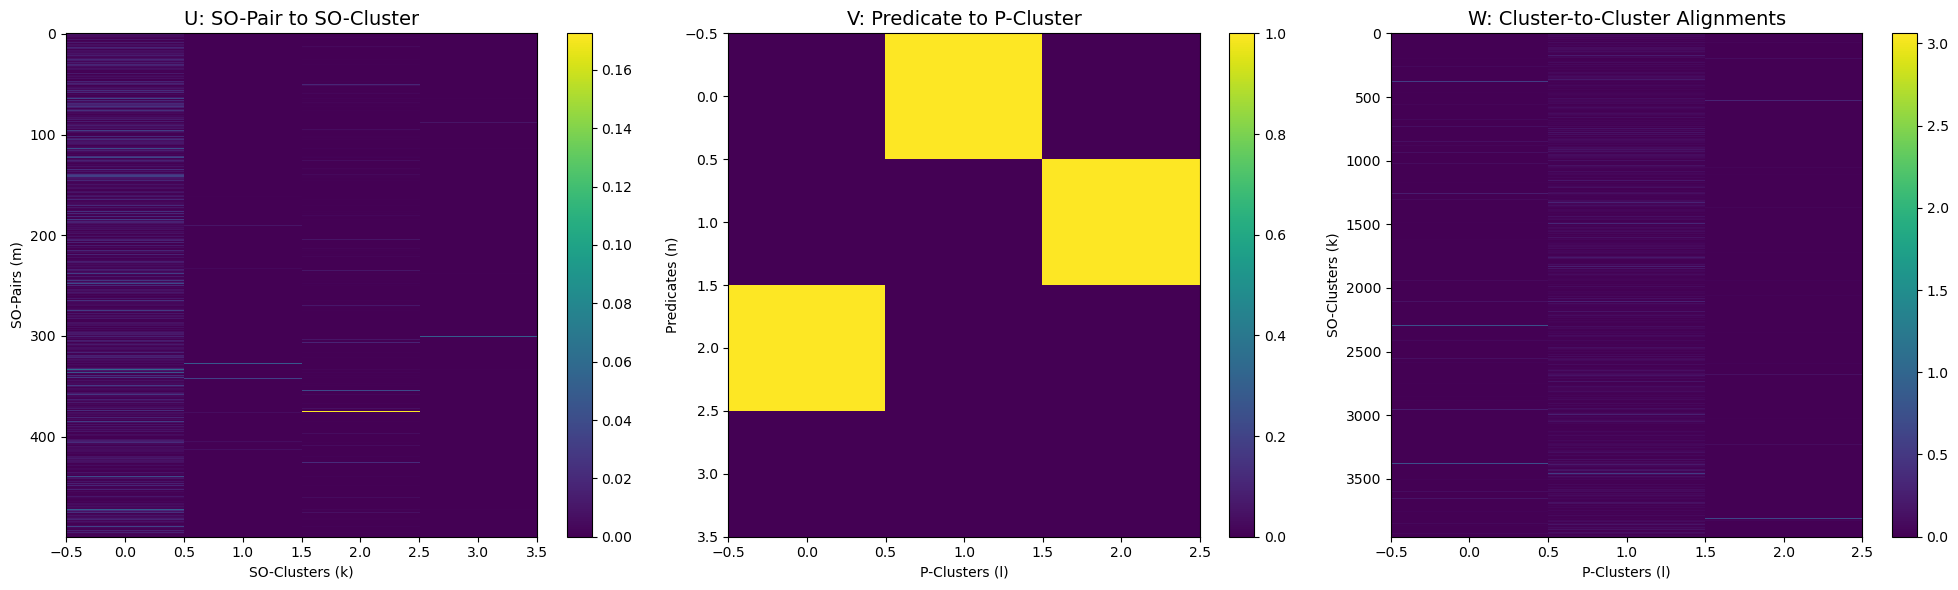

In [72]:
if __name__ == '__main__':
    main()